# Membrane thickness — analysis and visualization

This notebook covers post-pipeline analysis of the thickness and intensity profile files produced by `cryocat.analysis.memthick` (see tutorial [`memthick_run.ipynb`](memthick_run.ipynb)) via the `memthick_analyze_plot` module.  
It assumes that the `*_thickness.csv` + `*_int_profiles.pkl` files exist in your outputs folder.

---

## Table of contents

1. [Pipeline](#1-pipeline)
2. [Setup](#2-setup)
3. [Boundary mode summary](#3-boundary-mode-summary)
4. [Thickness distributions](#4-thickness-distributions)
5. [3D spatial visualization](#5-3d-spatial-visualization)
6. [Intensity profile summary](#6-intensity-profile-summary)
7. [Binned intensity profiles](#7-binned-intensity-profiles)
8. [Motl export](#8-motl-export)



---
## 1 Pipeline

### 1.1 The three steps

The `cryocat.analysis.memthick` pipeline runs in three sequential steps. The first two are geometric; the third identifies minima and inflection points to calculateunderl membrane thickness from the udnerlying tomogram intensity profiles.

| Step | Input | Output | What it computes |
|-------|-------|--------|-----------------|
| **1 — Surface extraction** | Segmentation MRC | `*_vertices_normals.csv` | Marching-cubes mesh of the membrane; surface normals; bilateral split into surface 1 / surface 2 |
| **2 — Geometric matching** | Vertex CSV | `*_matched_points.csv` | One-to-one normal-cone pairing between the two surfaces; records the Euclidean distance along the normal (`matched_points_distance_nm`) |
| **3 — Intensity profile analysis** | Matched pairs + tomogram MRC | `*_thickness.csv`, `*_int_profiles.pkl`, `*_boundary_stats.txt` | Short 1-D intensity profiles extracted along each matched pair; detection of leaflet minima and outward maxima; inflection-point-based membrane thickness |

Steps 1–2 are purely geometric — no tomogram is needed. Step 3 is where the membrane thickness is measured from the data.

---

### 1.2 What is membrane thickness here?

Two different distances appear in the output:

**`matched_points_distance_nm`** (geometric)  
The Euclidean distance between the matched segmentation surface points on surface 1 and surface 2, measured along the normal direction (hence, it's a property of the segmentation).

**`membrane_thickness_nm`** (profile-derived)  
The distance between the **inflection points** of the intensity profile on the left and right sides of the membrane. An inflection point lies on the steepest part of the intensity ramp between a leaflet minimum and its outward maximum — it marks where the density gradient is largest and the points where we choose to define thickness. The distances between minima are also reported in case that's the membrane thickness definition you'd prefer.

---

### 1.3 Intensity profile features

Each extracted profile runs along the vector connecting the matched point pair, centred at the geometric midpoint, and extends `profile_half_width_nm` in each direction.

The pipeline identifies five points per profile (where detectable):

| Point | Symbol | Description |
|----------|--------|-------------|
| Left leaflet minimum | `minima1` | Lowest intensity on the left side (phosphate headgroups) |
| Right leaflet minimum | `minima2` | Same on the right side |
| Central maximum | `central_max` | Peak between the two minima; the hydrophobic core |
| Left outward maximum | — | Peak outside (left of) `minima1` as the intensity returns to baseline |
| Right outward maximum | — | Peak outside (right of) `minima2` as the intensity returns to baseline |

The **inflection point** on each side lies on the slope between the leaflet minimum and the outward maximum — where intensity is changing fastest. Its position is found by a weighted-median slope analysis and refined by quadratic interpolation.

---

### 1.4 Detection modes — how `detection_mode` is assigned

Not every profile has a clear outward maximum on both sides. The pipeline handles this in two passes and records *how* each boundary was determined in the `detection_mode` column.

#### `max_max` — both boundaries from resolved outward maxima

Both the left and right outward maxima are found as genuine `find_peaks` peaks within `anchor_search_nm` of each leaflet minimum. The inflection point on each side is computed from the slope between the minimum and its maximum.

This is the **highest-confidence** assignment. Both sides of the membrane are well-resolved in the tomogram and the profile has a clear double-peak structure.

#### `max_anchor` / `anchor_max` — one boundary inferred by mirroring

One side has a clear outward maximum (`max`); the other does not. The missing side's anchor position is **predicted** by mirroring the max-to-min span from the good side. The inflection point is then computed normally between the minimum and the mirrored anchor.

- `max_anchor`: left side has a real maximum; right side uses a mirrored anchor.
- `anchor_max`: right side has a real maximum; left side uses a mirrored anchor.

Both are **moderate-confidence** assignments. The membrane boundary is physically present but the intensity peak on one side is too weak or poorly separated to be detected as a strict maximum. The mirrored position uses symmetry to estimate where it should be.

> In the analysis module, `max_anchor` and `anchor_max` are treated as equivalent and counted together. The distinction is preserved in the raw column for debugging.

#### `minima_only` — no inflection points; distance between minima

Neither outward maximum could be found. The pipeline falls back to reporting the **distance between the two leaflet minima** as `minima_separation_nm`.

- `membrane_thickness_nm` is set to **NaN** for these rows — they are different from inflection-point-based measurements.
- `minima_separation_nm` is always populated (for all rows, not just `minima_only`) and represents the inner minima-to-minima distance.
- `minima_only` rows appear in the exported CSV because they might still useful for spatial analysis.

**Summary table:**

| `detection_mode` | Left boundary | Right boundary | `membrane_thickness_nm` | `minima_separation_nm` |
|-----------------|--------------|---------------|------------------------|----------------------|
| `max_max` | Inflection point (real max) | Inflection point (real max) | ✓ | ✓ |
| `max_anchor` | Inflection point (real max) | Inflection point (mirrored) | ✓ | ✓ |
| `anchor_max` | Inflection point (mirrored) | Inflection point (real max) | ✓ | ✓ |
| `minima_only` | — | — | NaN | ✓ |

---

### 1.5 Output files

| File | Content |
|------|---------|
| `*_thickness.csv` | One row per resolved profile; coordinates, `membrane_thickness_nm` (NaN for `minima_only`), `minima_separation_nm`, `matched_points_distance_nm`, `detection_mode`, surface normals |
| `*_int_profiles.pkl` | List of profile dicts (same order as rows in `*_thickness.csv`); each dict contains the raw intensity array, pixel size, matched-point geometry, and a `features` sub-dict with all detected landmarks |
| `*_boundary_stats.txt` | Text summary of boundary-finding statistics from the pipeline run |


---
## 2 Setup

Point `output_path` and `seg_base` at your pipeline output folder.  
`membrane_names` should match the label strings used when the pipeline was run — they are part of the output filenames.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import memthick_analyze_plot as maple
from IPython.display import IFrame, Image

In [3]:
output_path = Path("outputs")
seg_base    = "2140_z150to400_segmented"

membrane_names = ["ER", "IMM", "OMM"]

# Helper: build the path to a named output file for a given membrane
def out(membrane, suffix):
    return output_path / f"{seg_base}_{membrane}_{suffix}"

# Quick check that expected files exist
for membrane in membrane_names:
    for suffix in ["thickness.csv", "int_profiles.pkl"]:
        p = out(membrane, suffix)
        status = "OK" if p.exists() else "MISSING"
        print(f"{membrane:4s}  {suffix}  →  {status}")

ER    thickness.csv  →  OK
ER    int_profiles.pkl  →  OK
IMM   thickness.csv  →  OK
IMM   int_profiles.pkl  →  OK
OMM   thickness.csv  →  OK
OMM   int_profiles.pkl  →  OK


### Load and analyse each membrane

`load_membrane_data` reads the thickness CSV and, when `auto_discover_related_files=True`,
automatically finds the matching `*_int_profiles.pkl` and `*_boundary_stats.txt` in the same folder.

`analyze_membrane_thickness` computes summary statistics (mean, median, std, percentiles).

`analyze_intensity_profiles` summarises the extracted profiles and can optionally bin them by thickness.

In [4]:
# Pixel size
pixel_size_nm      = None     # None → auto-read from pickle

# Thickness filtering
outlier_removal    = None     # None | 'iqr' | 'percentile' | 'std'

# Intensity profile axis
extension_range_nm = None     # None → inferred from profiles
                              # e.g. (-5.5, 5.5) to fix the x-axis window


In [5]:
membrane_data     = {}
thickness_results = {}
profile_results   = {}

for m in membrane_names:
    print(f"\n{'═'*60}")
    print(f"  {m}")
    print(f"{'═'*60}")

    # Load
    md = maple.load_membrane_data(
        thickness_csv=out(m, "thickness.csv"),
        auto_discover_related_files=True,
        pixel_size_nm=pixel_size_nm,
    )

    n_rows = len(md.thickness_df)
    n_prof = len(md.intensity_profiles)
    ps = (pixel_size_nm
          or (md.intensity_profiles[0].get("pixel_size") if md.intensity_profiles else None))
    ps_str = f"{ps:.4f} nm" if ps else "(unknown — pass pixel_size_nm)"
    print(f"  CSV rows : {n_rows:,}")
    print(f"  Profiles : {n_prof:,}")
    print(f"  Pixel size : {ps_str}")

    # Boundary mode counts
    info    = maple.return_boundary_info(md)
    n_res   = info["n_resolved"]
    n_inf   = info["n_finite_inflection_thickness_nm"]
    n_mo    = info["by_detection_mode"].get("minima_only", 0)
    n_unres = info["n_unresolved"]
    print(f"\n  Resolved : {n_res:,} / {n_rows:,}   Unresolved: {n_unres:,}")
    print(f"  Inflection thickness (non-NaN): {n_inf:,}")
    print(f"  Minima-only rows (NaN thickness, min–min dist): {n_mo:,}")
    if info["by_detection_mode"]:
        stages = "  ".join(f"{k}: {v:,}" for k, v in info["by_detection_mode"].items())
        print(f"  detection_mode → {stages}")

    # Thickness analysis
    tr = maple.analyze_membrane_thickness(
        data=md,
        outlier_removal_method=outlier_removal,
    )
    s = tr.statistics
    n_fin = s.get("count_finite", s["count"])
    print(f"\n  Thickness (nm)  n_finite={n_fin:,}")
    print(f"    mean ± std : {s['mean']:.3f} ± {s['std']:.3f}")
    print(f"    median     : {s['median']:.3f}")
    print(f"    IQR        : {s['q25']:.3f} – {s['q75']:.3f}")
    print(f"    range      : {s['min']:.3f} – {s['max']:.3f}")

    # Intensity profile analysis
    pr = maple.analyze_intensity_profiles(
        data=md,
        extension_range_nm=extension_range_nm,
    )
    ext = pr.parameters.get("extension_range_nm", "?")
    pix = pr.parameters.get("pixel_size_nm")
    pix_str = f"{pix:.4f} nm" if pix else "?"
    print(f"\n  Profiles analysed : {len(pr.profiles):,}")
    if ext != "?":
        print(f"  Extension range   : {ext[0]:.2f} – {ext[1]:.2f} nm")
    print(f"  Pixel size used   : {pix_str}")

    membrane_data[m]     = md
    thickness_results[m] = tr
    profile_results[m]   = pr



════════════════════════════════════════════════════════════
  ER
════════════════════════════════════════════════════════════
Loaded 172106 intensity profiles from outputs/2140_z150to400_segmented_ER_int_profiles.pkl
  CSV rows : 172,106
  Profiles : 172,106
  Pixel size : 0.7840 nm

  Resolved : 172,106 / 172,106   Unresolved: 0
  Inflection thickness (non-NaN): 148,714
  Minima-only rows (NaN thickness, min–min dist): 23,392
  detection_mode → max_max: 81,265  max_anchor: 67,449  minima_only: 23,392

  Thickness (nm)  n_finite=148,714
    mean ± std : 5.781 ± 0.824
    median     : 5.671
    IQR        : 5.251 – 6.248
    range      : 2.391 – 8.000
Analyzing 172106 intensity profiles...

  Profiles analysed : 172,106
  Extension range   : -5.50 – 5.50 nm
  Pixel size used   : 0.7840 nm

════════════════════════════════════════════════════════════
  IMM
════════════════════════════════════════════════════════════
Loaded 678130 intensity profiles from outputs/2140_z150to400_segmented

---
## 3 Boundary mode summary

`return_boundary_info` reads the `detection_mode` column of the loaded CSV and reports:

- **Total rows** — all rows in the exported CSV (all resolved by construction).
- **Inflection-point thickness rows** — rows with a finite `membrane_thickness_nm` (`max_max` + `max_anchor` + `anchor_max`).
- **Minima-only rows** — rows where `membrane_thickness_nm` is NaN; only `minima_separation_nm` is available.
- **Detection mode breakdown** — count per mode.


In [6]:
for membrane in membrane_names:
    print(f"\n{'='*60}")
    print(f"  {membrane}")
    print(f"{'='*60}")
    info = maple.return_boundary_info(membrane_data[membrane])
    print("\n".join(info["lines"]))


  ER
Source: thickness_csv  |  Rows: 172,106
Inflection (non-NaN thickness): 148,714  (86.4%)
Minima-only: 23,392  (13.6%)
Detection mode:  max_max 81,265  |  max_anchor 67,449  |  minima_only 23,392

  IMM
Source: thickness_csv  |  Rows: 678,130
Inflection (non-NaN thickness): 594,151  (87.6%)
Minima-only: 83,979  (12.4%)
Detection mode:  max_max 371,653  |  max_anchor 222,498  |  minima_only 83,979

  OMM
Source: thickness_csv  |  Rows: 495,947
Inflection (non-NaN thickness): 433,284  (87.4%)
Minima-only: 62,663  (12.6%)
Detection mode:  max_max 260,979  |  max_anchor 172,305  |  minima_only 62,663


---
## 4 Thickness distributions

### 4.1 — Single membrane

`plot_thickness_distribution` shows a histogram (and optional KDE) of `membrane_thickness_nm` for one or more membranes.

**Filtering parameters**:

| Parameter | Type | Description |
|-----------|------|-------------|
| `thickness_range_nm` | `(min, max)` or `None` | Display only rows with `membrane_thickness_nm` in this range. Rows with NaN thickness (minima_only) are dropped. |
| `minima_separation_range_nm` | `(min, max)` or `None` | Display only rows with `minima_separation_nm` in this range. Applied after `thickness_range_nm` (logical AND). |
| `thickness_regime` | `str` or `list[str]` or `None` | Keep only rows matching a `detection_mode` group: `"max_max"`, `"max_anchor"`, `"minima_only"`, or a list like `["max_max", "max_anchor"]`. |

**Other parameters:**

| Parameter | Type | Description |
|-----------|------|-------------|
| `histogram_bins` | `int` | Number of histogram bins. |
| `density_normalization` | `bool` | Normalise y-axis to probability density (area = 1). Useful when comparing membranes with very different row counts. |
| `show_mean_lines` | `bool` | Draw vertical lines at the mean and median. |
| `opacity` | `float` | Bar opacity (0–1); useful when overlaying multiple membranes. |


In [7]:
thickness_range_nm=(3.0, 8.0) #nm

In [8]:
fig = maple.plot_thickness_distribution(
    thickness_results["IMM"],
    membrane_names=["IMM"],
    thickness_range_nm=thickness_range_nm,
    histogram_bins=60,
    show_statistics=True,
    show_mean_lines=True,
    density_normalization=True,
)
#fig.show()
#fig.write_html("plots/IMM_thickness_distribution.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_thickness_distribution.png", width=800, height=600)


Statistics for IMM:
  Mean:   5.54
  Std:    0.81
  Median: 5.37
  Count:  594,044


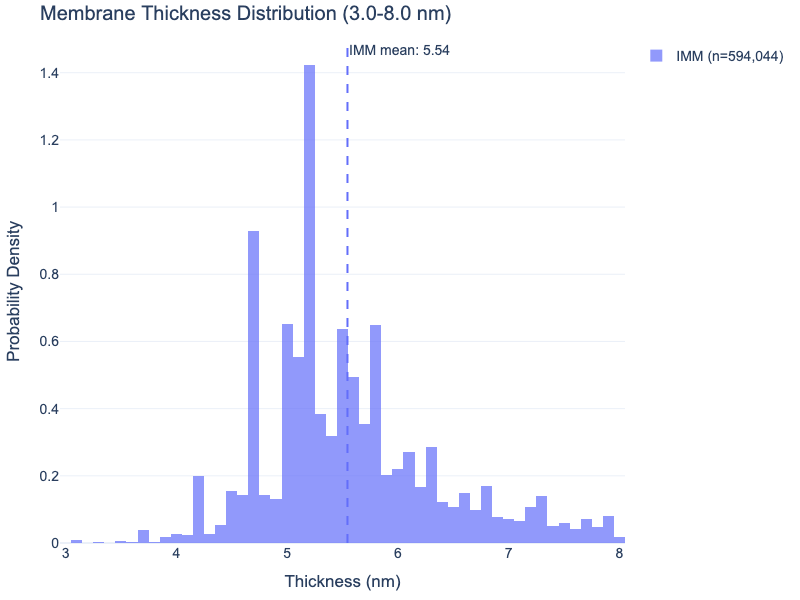

In [9]:
#IFrame("plots/IMM_thickness_distribution.html", width=800, height=600)
Image("plots/IMM_thickness_distribution.png", width=800, height=600)

### 4.2 Comparison of mutliple membranes

Pass a list of `ThicknessAnalysisResults` objects and a matching list of `membrane_names` to overlay distributions on the same axes.

In [10]:
fig = maple.plot_thickness_distribution(
    [thickness_results[m] for m in membrane_names],
    membrane_names=membrane_names,
    thickness_range_nm=thickness_range_nm,
    histogram_bins=60,
    density_normalization=True,
    show_mean_lines=True,
    opacity=0.6,
    plot_title="Membrane thickness comparison",
)
#fig.show()
#fig.write_html("plots/thickness_distribution_comparison.html", include_plotlyjs="cdn")
fig.write_image("plots/thickness_distribution_comparison.png", width=800, height=600)


Statistics for ER:
  Mean:   5.78
  Std:    0.82
  Median: 5.67
  Count:  148,655

Statistics for IMM:
  Mean:   5.54
  Std:    0.81
  Median: 5.37
  Count:  594,044

Statistics for OMM:
  Mean:   5.53
  Std:    0.87
  Median: 5.28
  Count:  433,194


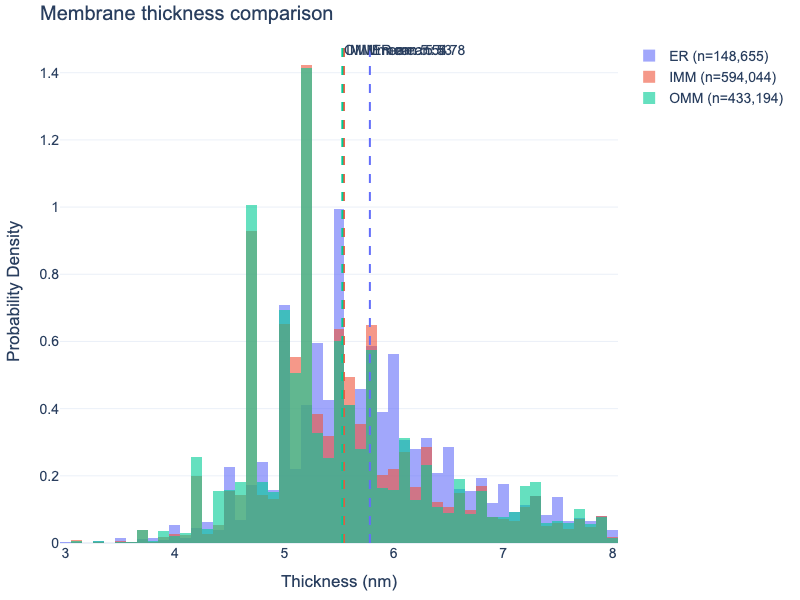

In [11]:
#IFrame("plots/thickness_distribution_comparison.html", width=800, height=600)
Image("plots/thickness_distribution_comparison.png", width=800, height=600)

### 4.3 — Leaflet min-to-min separation

`plot_min_to_min_distribution` plots the distance between the two detected minima (including `minima_only` rows where no other features were detected). You can disable this by setting `thickness_regime`.

In [12]:
fig = maple.plot_min_to_min_distribution(
    [thickness_results[m] for m in membrane_names],
    membrane_names=membrane_names,
    minima_separation_range_nm=(2.0, 7.0),
    histogram_bins=25,
    density_normalization=True,
    show_mean_lines=True,
    opacity=0.6,
    plot_title="Minima-to-minima distances",
)
#fig.show()
#fig.write_html("plots/min_min_distances.html", include_plotlyjs="cdn")
fig.write_image("plots/min_min_distances.png", width=800, height=600)


Statistics for ER:
  Mean:   4.76
  Std:    0.84
  Median: 4.68
  Count:  160,375

Statistics for IMM:
  Mean:   4.49
  Std:    0.86
  Median: 4.46
  Count:  642,328

Statistics for OMM:
  Mean:   4.49
  Std:    0.90
  Median: 4.46
  Count:  468,793


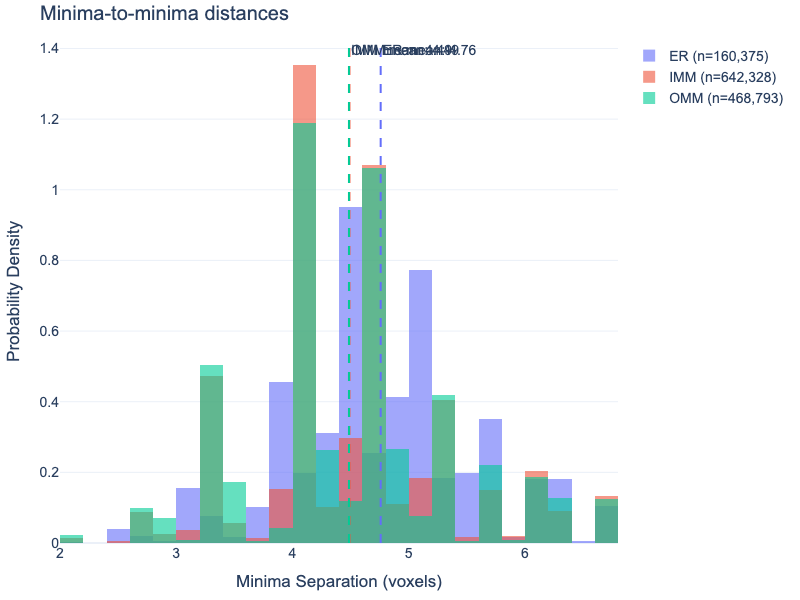

In [13]:
#IFrame("plots/min_min_distances.html", width=800, height=600)
Image("plots/min_min_distances.png", width=800, height=600)


---
## 5 3D spatial visualization

These plots render the membrane in voxel space and colour each point by its local thickness or by surface identity.

### 5.1 — Thickness map in voxel space

`plot_thickness_3d` colour-codes each matched-point location by `membrane_thickness_nm`. Use `sample_fraction` to reduce the number of points for interactive performance (`sample_fraction=0.3` keeps 30 % at random).

**Filtering parameters**:

| Parameter | Type | Description |
|-----------|------|-------------|
| `thickness_range_nm` | `(min, max)` or `None` | Display only rows with `membrane_thickness_nm` in this range. Rows with NaN thickness (minima_only) are dropped. |
| `minima_separation_range_nm` | `(min, max)` or `None` | Display only rows with `minima_separation_nm` in this range. Applied after `thickness_range_nm` (logical AND). |
| `thickness_regime` | `str` or `list[str]` or `None` | Keep only rows matching a `detection_mode` group: `"max_max"`, `"max_anchor"`, `"minima_only"`, or a list like `["max_max", "max_anchor"]`. |

**Other parameters**:

| Parameter | Type | Description |
|-----------|------|-------------|
| `sample_fraction` | `float` | Fraction of rows to display (random subsample). |
| `marker_size` | `int` | Point size in pixels. |
| `color_scale` | `str` | Any Plotly colorscale name (`"OrRd"`, `"Viridis"`, `"RdBu"`, etc.). |



In [14]:
fig = maple.plot_thickness_3d(
    [thickness_results[m] for m in membrane_names],
    membrane_names=membrane_names,
    thickness_range_nm=thickness_range_nm,
    sample_fraction=0.2, # helps with rendering
    marker_size=2,
    color_scale="OrRd",
)
#fig.show()
#fig.write_html("plots/comparison_thickness_3d.html", include_plotlyjs="cdn")
fig.write_image("plots/comparison_thickness_3d.png", width=800, height=600)


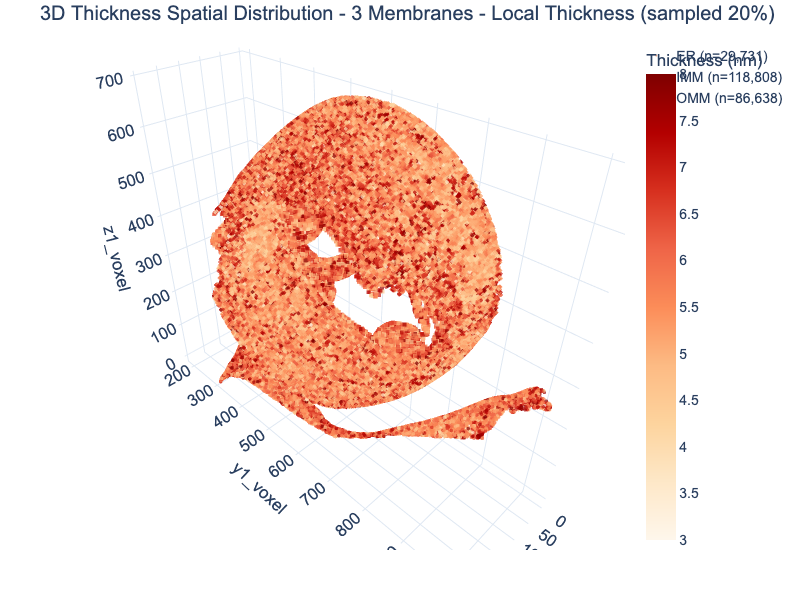

In [15]:
#IFrame("plots/comparison_thickness_3d.html", width=800, height=600)
Image("plots/comparison_thickness_3d.png", width=800, height=600)


### 5.2 — Surface 1 vs Surface 2 (point scatter or mesh)

`plot_surfaces` shows the two matched leaflet surfaces as coloured point clouds. By default, surface 1 (inner leaflet) is blue and surface 2 (outer leaflet) is orange.

When `save_split_surface_meshes=True` was passed to the pipeline, triangulated `.ply` meshes are written alongside the CSV. Pass `ply_base_path` to overlay the mesh. 

In [16]:
fig = maple.plot_surfaces(
    thickness_results["OMM"],
    membrane_names=["OMM"],
    sample_fraction=0.3,
    marker_size=2,
)
#fig.show()
#fig.write_html("plots/OMM_surface_scatter.html", include_plotlyjs="cdn")
fig.write_image("plots/OMM_surface_scatter.png", width=800, height=600)


OMM: Surface 1 points: 148,784, Surface 2 points: 148,784


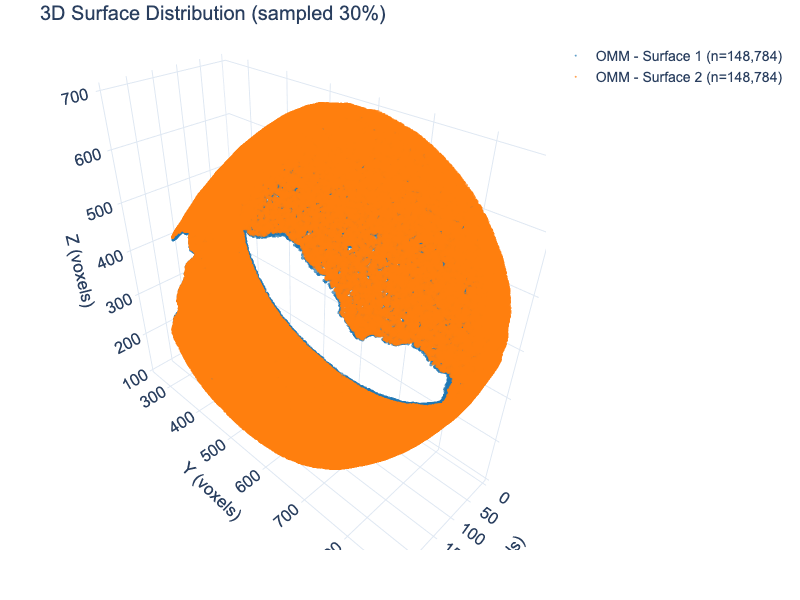

In [17]:
#IFrame("plots/OMM_surface_scatter.html", width=800, height=600)
Image("plots/OMM_surface_scatter.png", width=800, height=600)

In [18]:
fig = maple.plot_surfaces(
    thickness_results["OMM"],
    membrane_names=["OMM"],
    ply_base_path=output_path / seg_base,  # → outputs/2140_z150to400_segmented_OMM_surface1.ply
    mesh_opacity=0.5,
    show_scatter=False,  # mesh-only view; set True to see both
)
#fig.show()
#fig.write_html("plots/OMM_surface_mesh.html", include_plotlyjs="cdn")
fig.write_image("plots/OMM_surface_mesh.png", width=800, height=600)


OMM: Surface 1 points: 495,947, Surface 2 points: 495,947


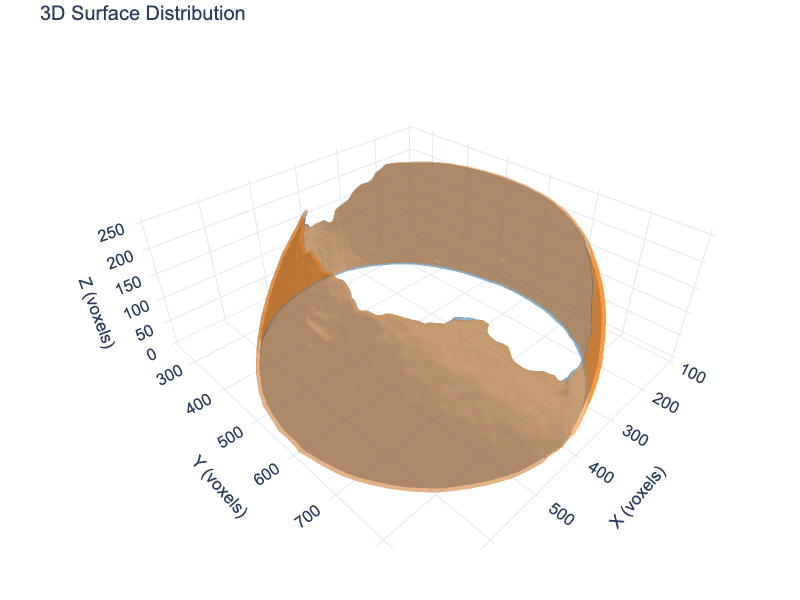

In [19]:
#IFrame("plots/OMM_surface_mesh.html", width=800, height=600)
Image("plots/OMM_surface_mesh.png", width=800, height=600)


---
## 6 Intensity profile summary

`plot_intensity_profile_summary` stacks all (or a filtered subset of) profiles, interpolates them onto a common distance axis, and shows the **mean profile** with a 25th–75th percentile intensity band.

Vertical markers show where key points fall on average across all included profiles.

**Marker display parameters:**

| Parameter | Default | What is shown |
|-----------|---------|---------------|
| `show_segmentation_boundary_markers` | `True` | Where the geometrically matched segmentation surface points project onto the profile. |
| `show_segmentation_boundary_distributions` | `True` | IQR shadow (25th–75th percentile) around the positions. |
| `show_inflection_point_markers` | `True` | Mean left and right inflection point positions. Their separation equals the mean `membrane_thickness_nm`. |
| `show_inflection_point_distributions` | `True` | IQR shadow around the inflection point positions. |
| `show_minima_midpoint` | `True` | Geometric midpoint between minima. |
| `show_minima` | `False` | Mean positions of the left and right minima. |
| `show_outward_maxima` | `False` | Mean positions of the outward maxima (one per side). Useful for debugging boundary detection. |

**Filtering parameters**:

| Parameter | Type | Description |
|-----------|------|-------------|
| `thickness_range_nm` | `(min, max)` or `None` | Display only rows with `membrane_thickness_nm` in this range. Rows with NaN thickness (minima_only) are dropped. |
| `minima_separation_range_nm` | `(min, max)` or `None` | Display only rows with `minima_separation_nm` in this range. Applied after `thickness_range_nm` (logical AND). |
| `thickness_regime` | `str` or `list[str]` or `None` | Keep only rows matching a `detection_mode` group: `"max_max"`, `"max_anchor"`, `"minima_only"`, or a list like `["max_max", "max_anchor"]`. |


### 6.1 — Show all profiles

In [20]:
fig = maple.plot_intensity_profile_summary(
    profile_results["IMM"],
    membrane_names=["IMM"],
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=True,
    show_inflection_point_markers=True,
    show_inflection_point_distributions=True,
    show_minima_midpoint=True,
    plot_title="IMM intensity profiles summary",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_summary.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_summary.png", width=800, height=600)


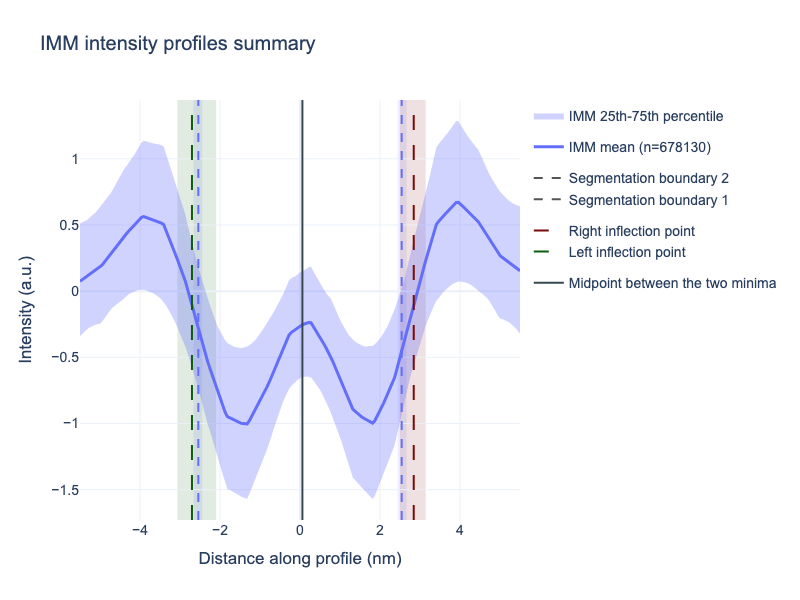

In [21]:
#IFrame("plots/IMM_profiles_summary.html", width=800, height=600)
Image("plots/IMM_profiles_summary.png", width=800, height=600)


### 6.2 — Filter by thickness regime

Plotting profiles split by `detection_mode` is useful for quality control: if `max_max` and `max_anchor` profiles might look different (different mean thickness, different profile shape)

The `thickness_regime` parameter accepts any of the detection mode names or a list of them:

```python
# Only profiles where both boundaries were detected from real maxima
thickness_regime="max_max"

# Only profiles where one boundary was inferred by mirroring (both left-real/right-mirrored and vice versa)
thickness_regime="max_anchor"


In [22]:
fig = maple.plot_intensity_profile_summary(
    profile_results["IMM"],
    membrane_names=["IMM"],
    thickness_regime="max_max",
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=True,
    show_inflection_point_markers=True,
    show_inflection_point_distributions=True,
    show_minima_midpoint=True,
    plot_title="IMM profiles with two resolved outward maxima",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_max_max.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_max_max.png", width=800, height=600)


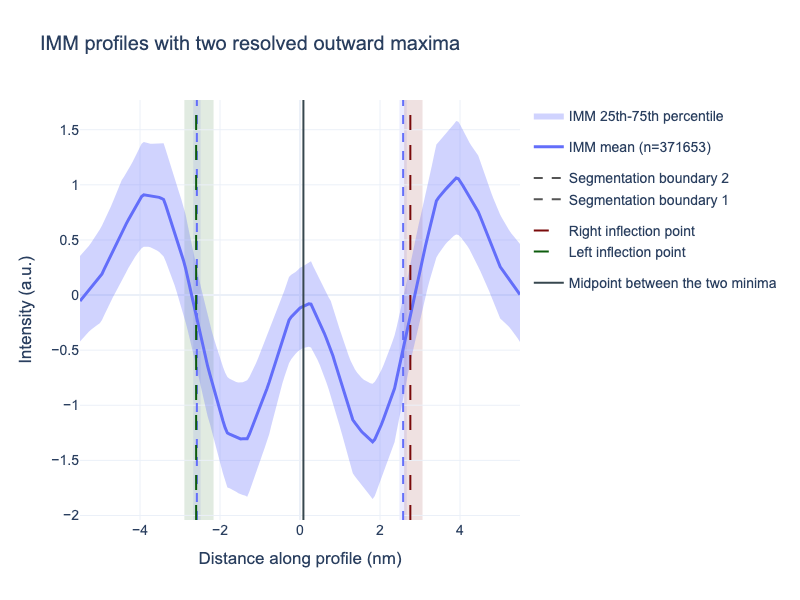

In [23]:
#IFrame("plots/IMM_profiles_max_max.html", width=800, height=600)
Image("plots/IMM_profiles_max_max.png", width=800, height=600)

In [24]:
fig = maple.plot_intensity_profile_summary(
    profile_results["IMM"],
    membrane_names=["IMM"],
    thickness_regime="max_anchor",
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=True,
    show_inflection_point_markers=True,
    show_inflection_point_distributions=True,
    show_minima_midpoint=True,
    plot_title="IMM profiles with one resolved outward maxima and one inferred boundary",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_max_anchor.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_max_anchor.png", width=800, height=600)


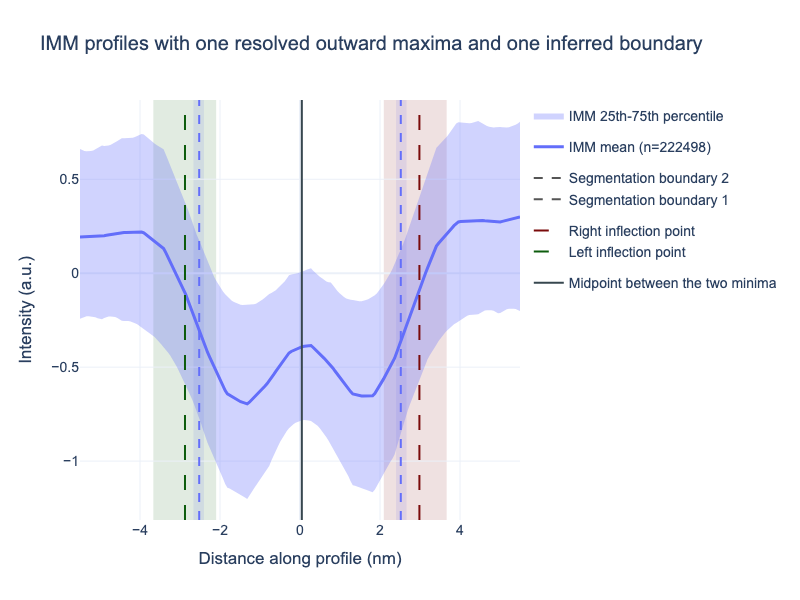

In [25]:
#IFrame("plots/IMM_profiles_max_anchor.html", width=800, height=600)
Image("plots/IMM_profiles_max_anchor.png", width=800, height=600)

### 6.3 — Filter by thickness range

Combine `thickness_range_nm` with `thickness_regime` to isolate a specific population — for example, profiles in the 4–5 nm range.

In [26]:
fig = maple.plot_intensity_profile_summary(
    profile_results["IMM"],
    membrane_names=["IMM"],
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=True,
    show_inflection_point_markers=True,
    show_inflection_point_distributions=True,
    show_outward_maxima=True,
    show_minima=True,
    show_minima_midpoint=True,
    thickness_range_nm=(4.0, 5.0),
    plot_title="IMM profiles in the 4-5 nm thickness range",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_4_5nm.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_4_5nm.png", width=800, height=600)


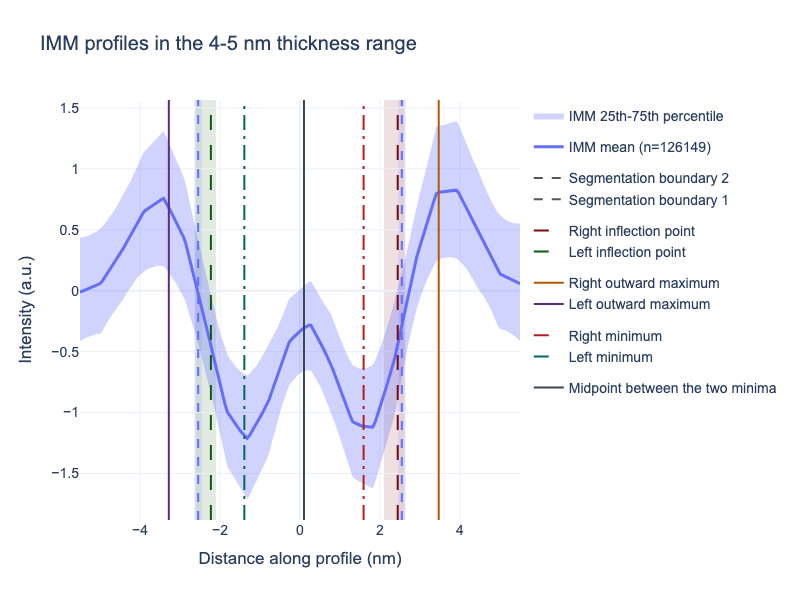

In [27]:
#IFrame("plots/IMM_profiles_4_5nm.html", width=800, height=600)
Image("plots/IMM_profiles_4_5nm.png", width=800, height=600)


---
## 7 Binned intensity profiles

`plot_intensity_profile_binned` splits profiles into thickness bins and plots the **mean profile per bin**. This reveals whether the profile shape changes with membrane thickness — for example, thicker membranes might show a broader central maximum or more separated minima.

**Binning methods:**

| `binning_method` | Description |
|-----------------|-------------|
| `"quantile"` (default) | Equal number of profiles per bin. Each bin has the same statistical weight. |
| `"equal_width"` | Equal nm range per bin. Bins near the mode of the distribution will contain far more profiles than tails. |
| Custom list | Pass `[(min1, max1, "label1"), (min2, max2, "label2"), ...]` to define arbitrary windows. |

**Key parameters:**

| Parameter | Type | Description |
|-----------|------|-------------|
| `thickness_bins` | `int` or list or `None` | Number of auto-bins, explicit bin list, or `None` (defaults to 4 quartiles). |
| `binning_method` | `str` | `"quantile"` or `"equal_width"`. Ignored when a custom bin list is passed. |

### 7.1 — Equal number of profiles per bin

In [28]:
fig = maple.plot_intensity_profile_binned(
    profile_results["IMM"],
    membrane_names=["IMM"],
    thickness_bins=4,
    binning_method="quantile",
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=False, # too crowded
    show_inflection_point_markers=True,
    show_inflection_point_distributions=False, # too crowded
    show_minima_midpoint=False,
    plot_title="IMM profiles binned by thickness quartiles",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_binned_quartiles.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_binned_quartiles.png", width=800, height=600)


Using 4 bins (thickness_nm) for IMM:
  Bin 1 (infl.): 2.1-5.0 nm: 148,538 profiles
  Bin 2 (infl.): 5.0-5.4 nm: 148,538 profiles
  Bin 3 (infl.): 5.4-5.9 nm: 148,538 profiles
  Bin 4 (infl.): 5.9-8.0 nm: 148,538 profiles


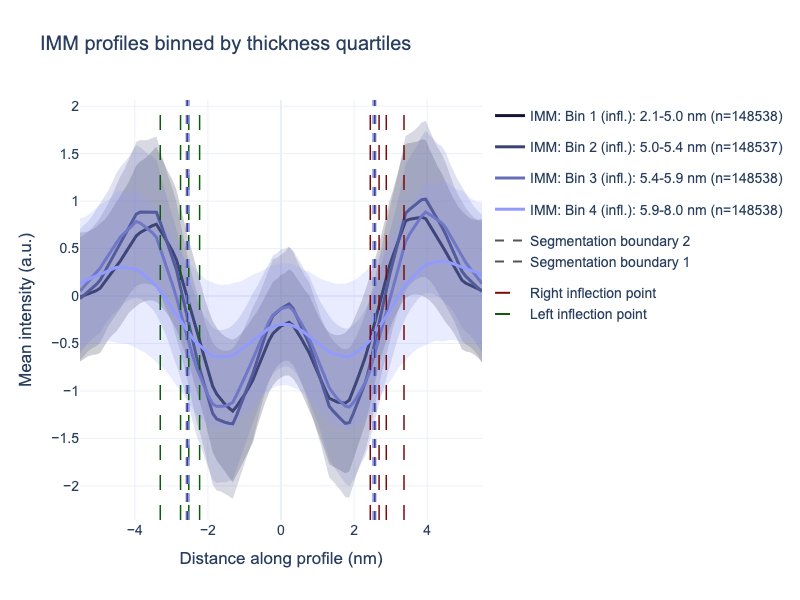

In [29]:
#IFrame("plots/IMM_profiles_binned_quartiles.html", width=800, height=600)
Image("plots/IMM_profiles_binned_quartiles.png", width=800, height=600)

### 7.2 — Equal-width bins

In [30]:
fig = maple.plot_intensity_profile_binned(
    profile_results["IMM"],
    membrane_names=["IMM"],
    thickness_bins=4,
    binning_method="equal_width",
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=False, # too crowded
    show_inflection_point_markers=True,
    show_inflection_point_distributions=False, # too crowded
    show_minima_midpoint=False,
    plot_title="IMM profiles binned by equal width thickness ranges",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_binned_equal_width.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_binned_equal_width.png", width=800, height=600)


Using 4 bins (thickness_nm) for IMM:
  Bin 1 (infl.): 2.1-3.6 nm: 1,256 profiles
  Bin 2 (infl.): 3.6-5.0 nm: 150,500 profiles
  Bin 3 (infl.): 5.0-6.5 nm: 367,114 profiles
  Bin 4 (infl.): 6.5-8.0 nm: 75,281 profiles


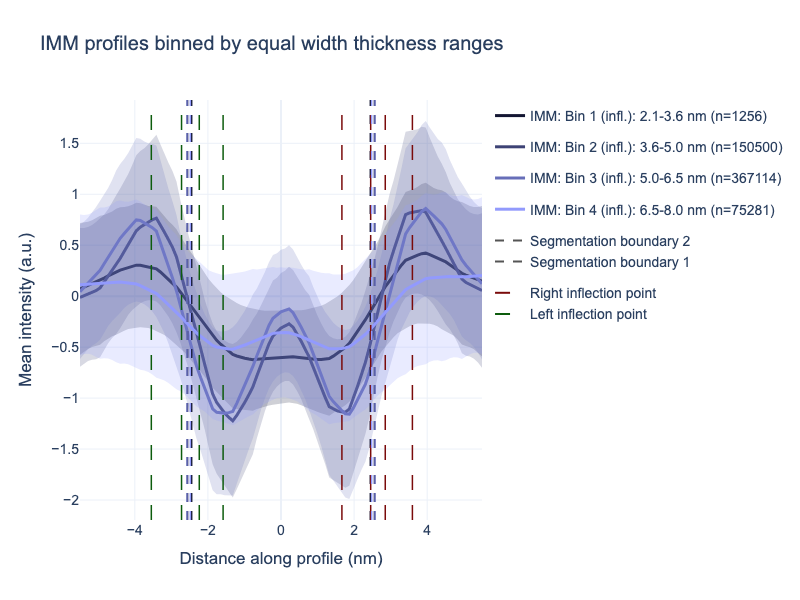

In [31]:
#IFrame("plots/IMM_profiles_binned_equal_width.html", width=800, height=600)
Image("plots/IMM_profiles_binned_equal_width.png", width=800, height=600)


### 7.3 — Custom thickness windows

Pass explicit `(min_nm, max_nm, label)` tuples to define your own bins.

In [32]:
fig = maple.plot_intensity_profile_binned(
    profile_results["IMM"],
    membrane_names=["IMM"],
    thickness_bins=[
        (0.0, 4.0,  "< 4 nm"),
        (4.0, 5.0,  "4 – 5 nm"),
        (5.0, 6.0,  "5 – 6 nm"),
        (6.0, 20.0, "> 6 nm"),
    ],
    show_segmentation_boundary_markers=True,
    show_segmentation_boundary_distributions=False, # too crowded
    show_inflection_point_markers=True,
    show_inflection_point_distributions=False, # too crowded
    show_minima_midpoint=False,
    plot_title="IMM profiles binned by custom thickness ranges",
)
#fig.show()
#fig.write_html("plots/IMM_profiles_binned_custom.html", include_plotlyjs="cdn")
fig.write_image("plots/IMM_profiles_binned_custom.png", width=800, height=600)


Using 4 bins (thickness_nm) for IMM:
  < 4 nm: 5,753 profiles
  4 – 5 nm: 126,149 profiles
  5 – 6 nm: 325,143 profiles
  > 6 nm: 137,394 profiles


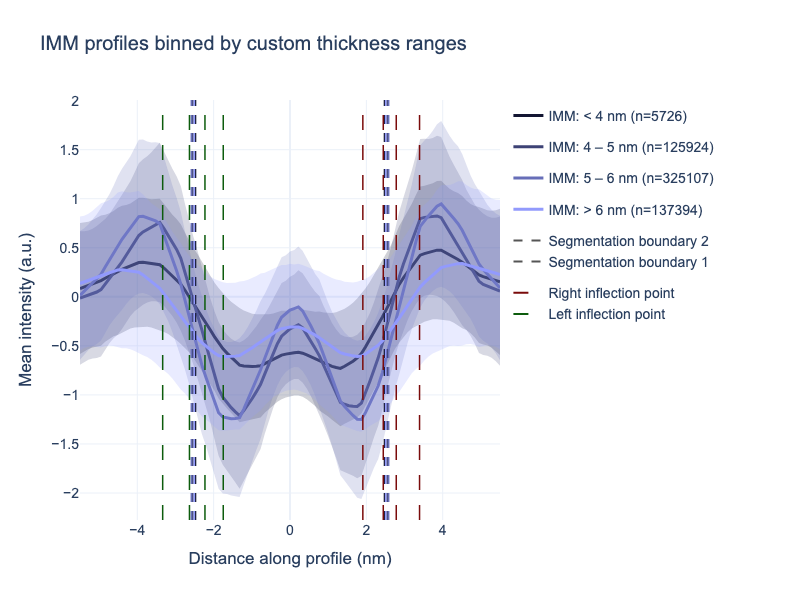

In [33]:
#IFrame("plots/IMM_profiles_binned_custom.html", width=800, height=600)
Image("plots/IMM_profiles_binned_custom.png", width=800, height=600)


---
## 8 Motl export

`save_thickness_motls` writes motive-list `.em` files (one for each surface) containing the matched-point XYZ coordinates, Euler angles derived from the surface normals, and the local `membrane_thickness_nm` as the score column.

These files can be opened in ChimeraX for spatial visualization of the thickness map and overlaid with the tomogram.

**Key parameters:**

| Parameter | Type | Description |
|-----------|------|-------------|
| `thickness_csv` | path | Path to the `*_thickness.csv` output from Stage 3. |
| `thickness_mode` | `str` | `"auto"` infers the mode from the filename (recommended). Use `"inflection_points"` or `"minima"` to override. |
| `sample_fraction` | `float` | Write a subsampled motl alongside the full one — useful for faster visualization in ChimeraX without loading hundreds of thousands of subtomograms. |
| `output_path` | path | Directory for the output `.em` files. |


In [34]:
for m in membrane_names:
    maple.save_thickness_motls(
        thickness_csv=out(m, "thickness.csv"),
        sample_fraction=0.15, # for easier visualization in ChimeraX
        output_path=output_path,
        thickness_mode="auto",
    )
    print(f"{m}: done")

Saved full motls with 172106 points
Saved subsampled motls with 25815 points
ER: done
Saved full motls with 678130 points
Saved subsampled motls with 101719 points
IMM: done
Saved full motls with 495947 points
Saved subsampled motls with 74392 points
OMM: done
